### Visualizing Mixture Distributions and Layers for Actuarial Science

Example visualizations for distributions, mixture distributions, and limited distributions to help explain actuarial layers and limited expected value (LEV.)

In [1]:
from scipy.stats import (
    norm,
    lognorm,
    skewnorm,
    genhyperbolic,
    expon,
    beta,
    poisson,
    nbinom,
)

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import simpson as simpsons_rule
from scipy.optimize import brentq

In [2]:
# Function to visualize an rv_continuous_frozen object
def plot_dist(dist, discrete: bool = None):

    if discrete is None:
        discrete = hasattr(dist, "pmf")
    else:
        discrete = bool(discrete)

    # Compute statistics
    mean, var, skew, kurtosis = dist.stats(moments="mvsk")

    # Generate data for PDF and CDF
    if discrete:
        x = np.arange(
            np.floor(dist.ppf(0.001)),
            np.ceil(dist.ppf(0.99)),
        )
    else:
        x = np.linspace(
            dist.ppf(0.001),
            dist.ppf(0.99),
            1000,
        )

    # Generate random samples
    random_samples = dist.rvs(size=10_000)

    # Create figure with 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # Plot PMF
    if discrete:
        axes[0, 0].margins(y=0)
        axes[0, 0].vlines(x, 0, dist.pmf(x), colors="blue", label="PMF")
        axes[0, 0].legend()
        axes[0, 0].set_title("Probability Mass Function (PMF)")

    # Plot PDF
    if not discrete:
        axes[0, 0].plot(x, dist.pdf(x), label="PDF")
        axes[0, 0].axvline(mean, linestyle="dashed", lw=1, color="black")
        axes[0, 0].legend()
        axes[0, 0].set_title("Probability Density Function (PDF)")

    # Plot CDF
    if discrete:
        axes[0, 1].step(
            x,
            dist.cdf(x),
            where="post",
            label="CDF",
            color="orange",
        )
    else:
        axes[0, 1].plot(
            x,
            dist.cdf(x),
            label="CDF",
            color="orange",
        )

    axes[0, 1].axvline(mean, linestyle="dashed", lw=1, color="black")
    axes[0, 1].legend()
    axes[0, 1].set_title("Cumulative Distribution Function (CDF)")

    # Scatter plot of random samples
    scatter_samples = random_samples[:500]
    axes[1, 0].scatter(
        range(len(scatter_samples)),
        scatter_samples,
        alpha=0.5,
        s=1,
    )
    axes[1, 0].set_title("Scatter Plot of Random Samples")
    axes[1, 0].set_xlabel("Sample Index")
    axes[1, 0].set_ylabel("Sample Value")

    # Histogram of random samples
    if discrete:
        bins = np.arange(
            np.floor(dist.ppf(0.001)) - 0.5,
            np.ceil(dist.ppf(0.999)) + 1.5,
        )
    else:
        bins = 30

    axes[1, 1].hist(
        random_samples,
        bins=bins,
        color="green",
        alpha=0.7,
    )

    axes[1, 1].text(
        0.75,
        0.95,
        f"Mean: {mean:.2f}\n"
        f"Var: {var:.2f}\n"
        f"Skew: {skew:.2f}\n"
        f"Kurtosis: {kurtosis:.2f}",
        transform=axes[1, 1].transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.7,
        ),
    )

    axes[1, 1].set_title("Histogram of Random Samples")
    axes[1, 1].set_xlabel("Value")
    axes[1, 1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

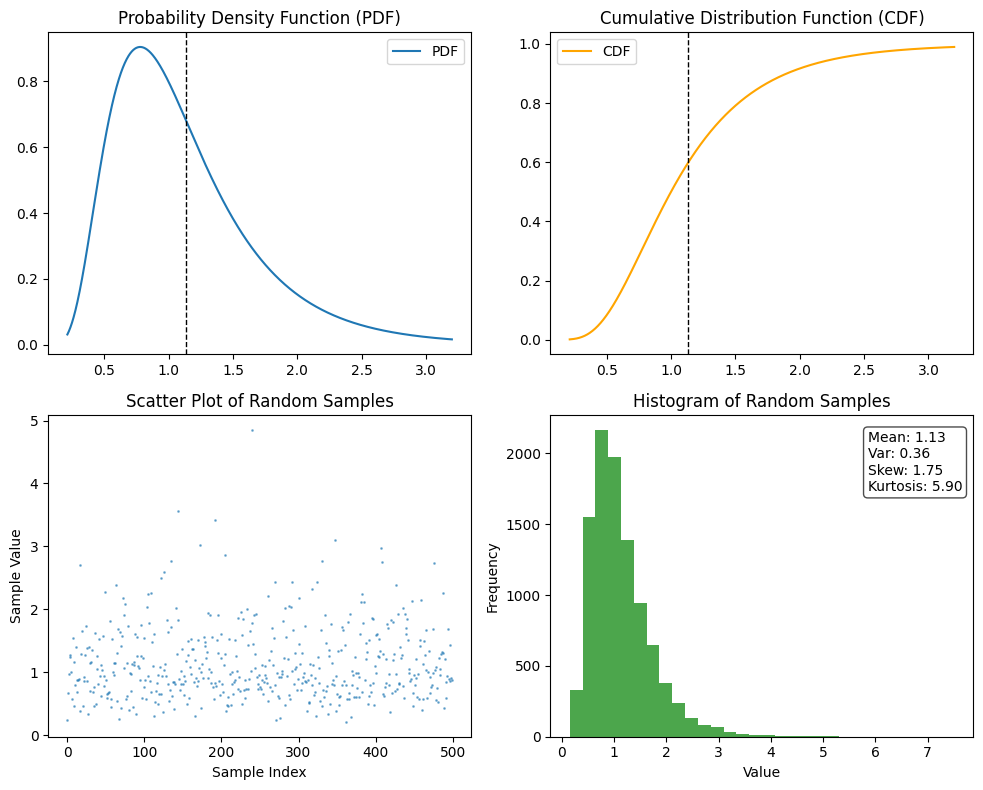

In [3]:
# continuous distribution
plot_dist(lognorm(s=0.5))

# try also:
# plot_dist(skewnorm(a=5))
# plot_dist(norm())
# plot_dist(beta(a=0.8342126163251065, b=2.9616671511379695))
# plot_dist(expon(scale=1))
# plot_dist(genhyperbolic(loc=4, scale=3, p=0.5, a=2, b=1))
# plot_dist(beta(a=3, b=50))

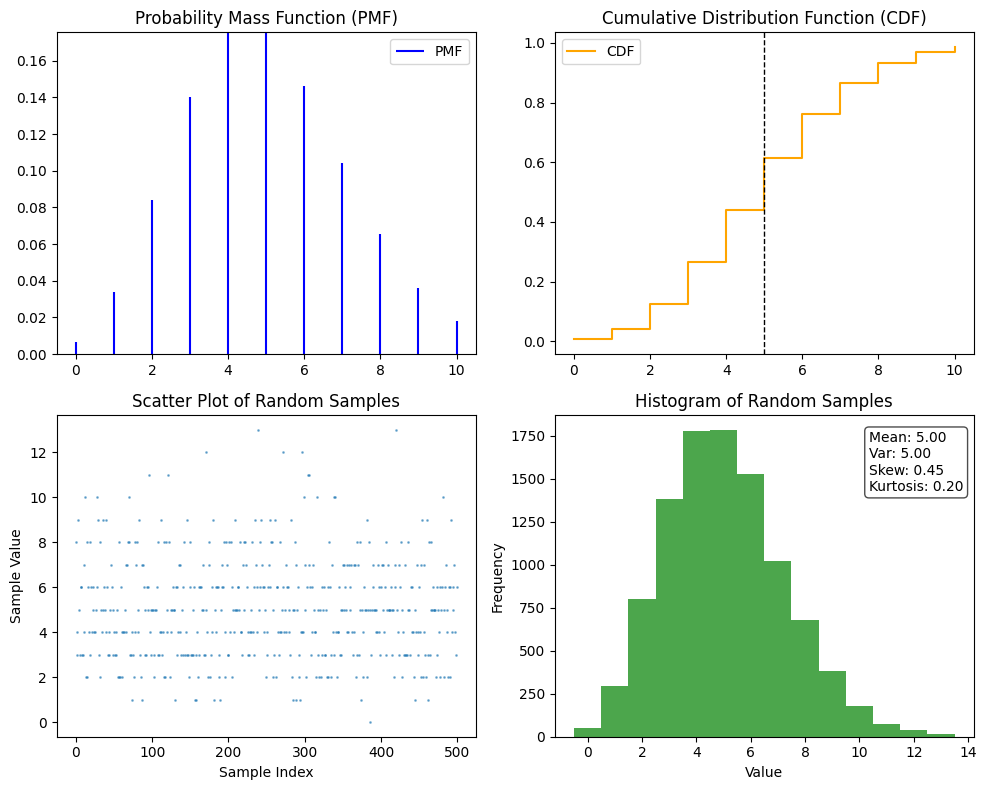

In [4]:
# discrete distribution
plot_dist(poisson(mu=5))

# try also:
# plot_dist(nbinom(10, 0.5))

In [12]:
def plot_layer(dist, lower: float, upper: float, discrete=None) -> float:
    """
    Let's say the RV X has the distribution `dist`.

    Then Y = 0 if X < lower,
         Y = X - lower if lower <= X <= upper,
    and  Y = (upper - lower) if X > upper.

    Calculate and visualize E[Y].

    Parameters:
    dist (rv_continuous or rv_discrete): The original distribution.
    lower (float): The lower boundary for truncation.
    upper (float): The upper boundary for truncation.
    discrete (bool, optional): Force the function to treat the
        distribution as discrete.

    Returns:
    float: The expected value of Y.
    """

    if discrete is None:
        discrete = hasattr(dist, "pmf")
    else:
        discrete = bool(discrete)

    layer_range = upper - lower
    mean, var, skew, kurtosis = dist.stats(moments="mvsk")

    # Generate x values for the entire range
    if discrete:
        x_full = np.arange(
            np.floor(dist.ppf(0.001)),
            np.ceil(dist.ppf(0.999)) + 1,
        )
        x_layer = np.arange(
            np.ceil(lower),
            np.floor(upper) + 1,
        )
    else:
        x_full = np.linspace(
            dist.ppf(0.001),
            dist.ppf(0.999),
            1000,
        )
        x_layer = np.linspace(
            lower,
            upper,
            500,
        )

    # Compute probabilities in the truncated areas
    p_below = dist.cdf(lower)
    p_layer = dist.cdf(upper) - p_below
    p_above = 1 - dist.cdf(upper)

    # Compute the new expectation E(Y)
    if discrete:
        # Sum the PMF in the range
        expectation_middle = np.sum(
            (x_layer - lower) * dist.pmf(x_layer)
        )
    else:
        # Integration over the middle area for the adjusted value
        expectation_middle = simpsons_rule(
            (x_layer - lower) * dist.pdf(x_layer),
            x=x_layer,
        )

    # LEV: Limited Expected Value
    lev = expectation_middle + p_above * layer_range

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.margins(y=0)

    # Plot and shade the layer region
    if discrete:
        full_pmf = dist.pmf(x_full)
        layer_pmf = dist.pmf(x_layer)

        stem_args = dict(
            linefmt="lightgray",
            markerfmt=" ",
            basefmt=" ",
        )

        ax.stem(
            x_full,
            full_pmf,
            label="Full PMF",
            **stem_args,
        )

        ax.stem(
            x_layer,
            layer_pmf,
            label="Layer PMF",
            **stem_args,
        )

        # Shade only between the first and last spike inside the layer
        if len(x_layer) > 0:
            ax.fill_between(
                x_layer,
                0,
                layer_pmf,
                color="blue",
                alpha=0.1,
            )

    else:
        full_pdf = dist.pdf(x_full)
        layer_pdf = dist.pdf(x_layer)

        ax.plot(
            x_full,
            full_pdf,
            label="Full PDF",
            lw=1,
            alpha=0.5,
            color="grey",
            linestyle="dashed",
        )

        ax.plot(
            x_layer,
            layer_pdf,
            label="Truncated PDF",
            color="darkblue",
        )

        ax.fill_between(
            x_layer,
            0,
            layer_pdf,
            color="blue",
            alpha=0.1,
        )

    # 5% top margin only
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(bottom=0, top=ymax * 1.05)

    # Plot the PMF at 0 and (upper - lower) using stems
    for limit in [lower, upper]:
        ax.axvline(
            limit,
            linestyle="dotted",
            lw=1,
            color="lightgray",
        )

    # Set labels and title
    ax.set_title("Layer Visualization")
    ax.set_xlabel("Value of Y")
    ax.set_ylabel("Probability")

    annotation_text = (
        f"$P_{{below}}$: {p_below:.3f}\n"
        f"$P_{{layer}}$: {p_layer:.3f}\n"
        f"$P_{{above}}$: {p_above:.3f}\n"
        f"LEV: {lev:.4f}"
    )

    ax.text(
        0.82,
        0.95,
        annotation_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.7,
        ),
    )
    plt.tight_layout()
    plt.show()

    return lev

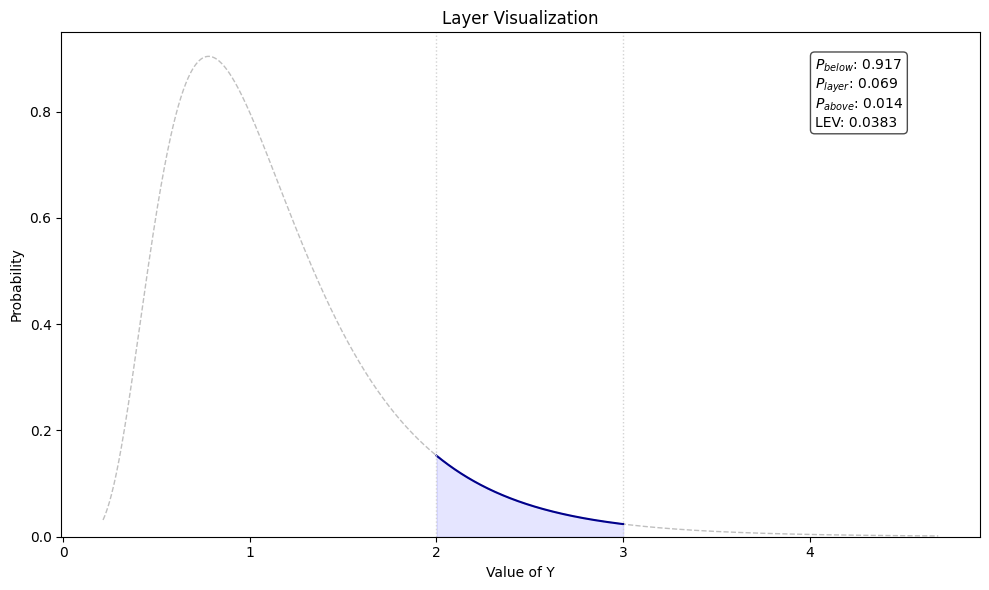

In [13]:
lev = plot_layer(lognorm(s=0.5), lower=2, upper=3)

# try also:
# lev = plot_layer(skewnorm(a=5), lower=2, upper=3)

In [14]:
class Mixture:
    def __init__(self, distributions, weights):
        self.distributions = distributions
        self.weights = np.asarray(weights) / np.sum(weights)

    def cdf(self, x):
        return np.sum(
            [w * d.cdf(x) for w, d in zip(self.weights, self.distributions)],
            axis=0,
        )

    def pdf(self, x):
        return np.sum(
            [
                w * d.pdf(x)
                for w, d in zip(self.weights, self.distributions)
            ],
            axis=0,
        )

    # def pmf(self, x):
    #     return np.sum(
    #         [
    #             w * d.pmf(x)
    #             for w, d in zip(self.weights, self.distributions)
    #         ],
    #         axis=0,
    #     )

    def rvs(self, size=1):
        num_samples = np.random.multinomial(
            size,
            self.weights,
        )

        samples = np.concatenate(
            [
                d.rvs(n) if n > 0 else np.array([])
                for d, n in zip(
                    self.distributions,
                    num_samples,
                )
            ]
        )

        np.random.shuffle(samples)
        return samples

    def ppf(self, q):
        # Numerically solve for the inverse CDF
        def cdf_minus_q(x):
            return self.cdf(x) - q

        # Use Brent's method to find the root
        return brentq(cdf_minus_q, -1e12, 1e12)

    def stats(self, moments="mv"):
        mean = np.sum(
            [
                w * d.stats("m")
                for w, d in zip(
                    self.weights,
                    self.distributions,
                )
            ]
        )

        var = np.sum(
            [
                w
                * (
                    d.stats("v")
                    + (d.stats("m") - mean) ** 2
                )
                for w, d in zip(
                    self.weights,
                    self.distributions,
                )
            ]
        )

        skew = np.sum(
            [
                (
                    w
                    * (
                        d.stats("s")
                        * d.stats("v") ** 0.5
                    ) ** 3
                    + 3
                    * (d.stats("m") - mean)
                    * d.stats(moments="v")
                    + (d.stats("m") - mean) ** 3
                )
                for w, d in zip(
                    self.weights,
                    self.distributions,
                )
            ]
        ) / var ** 1.5

        kurt = np.sum(
            [
                (
                    w
                    * (
                        d.stats("k")
                        * (d.stats("v") ** 2)
                        + 4
                        * d.stats("s")
                        * (d.stats("v") ** 1.5)
                        * (d.stats("m") - mean)
                        + 6
                        * (d.stats("v"))
                        * (d.stats("m") - mean) ** 2
                        + (d.stats("m") - mean) ** 4
                    )
                )
                for w, d in zip(
                    self.weights,
                    self.distributions,
                )
            ]
        ) / var ** 2 - 3

        results = {
            "m": mean,
            "v": var,
            "s": skew,
            "k": kurt,
        }

        return tuple(results[m] for m in moments)

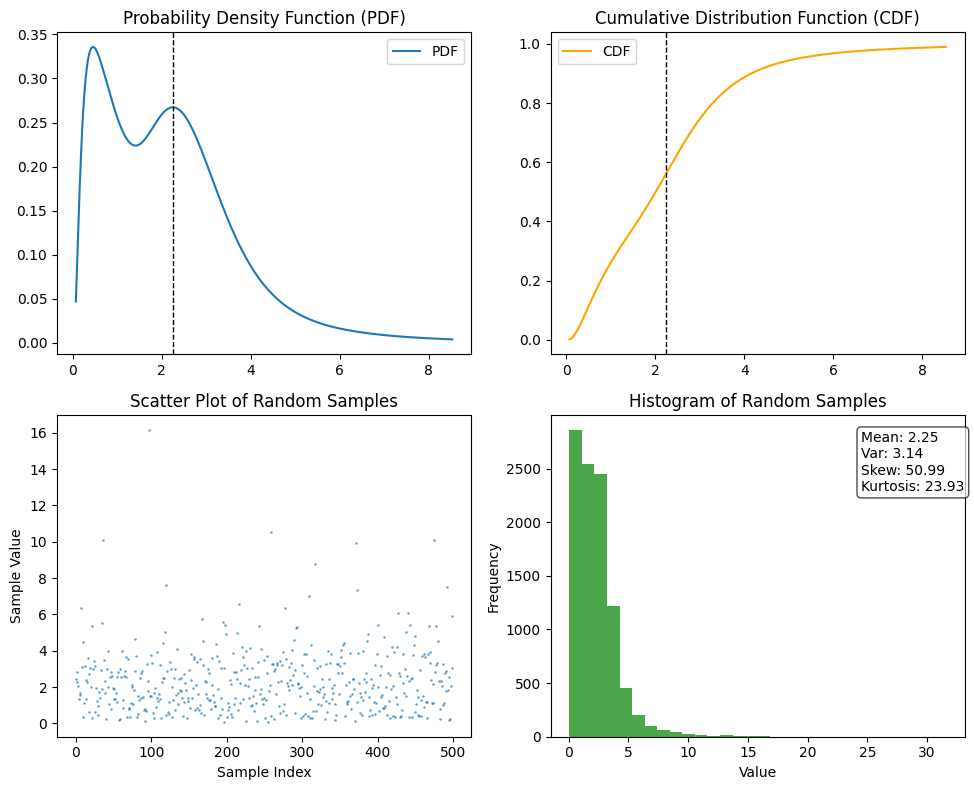

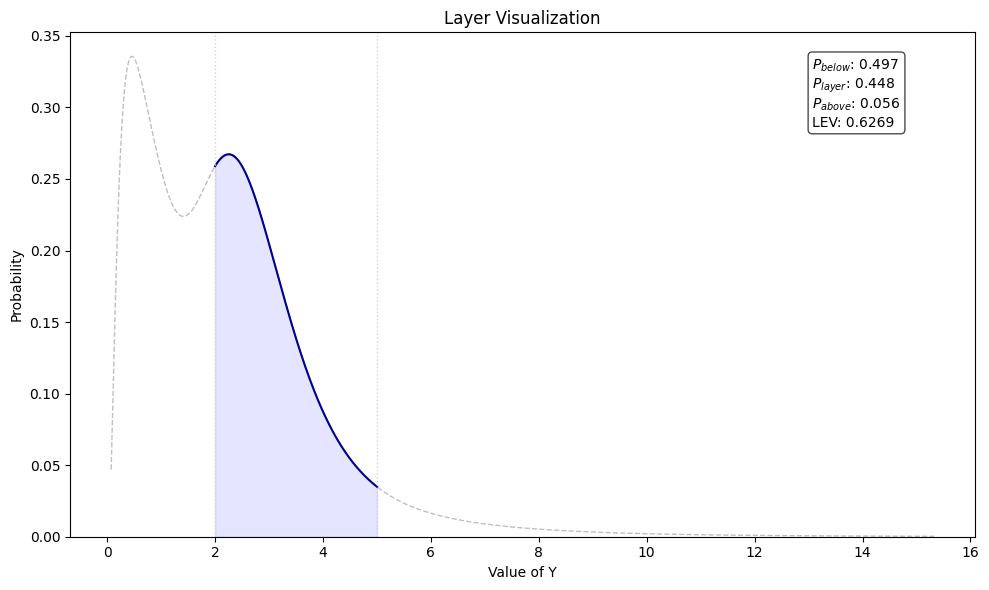

In [15]:
# Lognormal mixture with layer
lognormal_mixture = Mixture(
    [
        lognorm(s=0.3, scale=np.exp(1.0)),
        lognorm(s=0.6, scale=np.exp(1.0)),
        lognorm(s=0.9, scale=np.exp(0.0)),
    ],
    weights=[0.3, 0.2, 0.5],
)

plot_dist(lognormal_mixture)
lev = plot_layer(lognormal_mixture, lower=2, upper=5)

# try also:
# exponential_mixture = Mixture([
#     expon(scale=3),
#     expon(scale=5),
#     expon(scale=10)
# ], weights=[0.75, 0.20, 0.05])
# plot_dist(exponential_mixture)
# lev = plot_layer(exponential_mixture, lower=3, upper=5)

# or:
# gaussian_mixture = Mixture(
#     [norm(), norm(3)],
#     weights=[0.6, 0.4],
# )
# plot_dist(gaussian_mixture)
# lev = plot_layer(gaussian_mixture, lower=3, upper=5)

In [16]:
%pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [17]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def _dist_from_controls(name, mu, sigma):
    sigma = max(float(sigma), 1e-6)

    if name == "Normal":
        return norm(loc=mu, scale=sigma)

    if name == "Lognormal":
        return lognorm(s=sigma, scale=np.exp(mu))

    if name == "Skew Normal":
        return skewnorm(a=5, loc=mu, scale=sigma)

    if name == "Exponential":
        return expon(scale=max(mu, 1e-6))

    raise ValueError(f"Unknown distribution: {name}")


def _make_mixture(distributions, weights):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    try:
        mixture = Mixture(distributions, weights=weights)
    except TypeError:
        mixture = Mixture()
        mixture.distributions = distributions
        mixture.weights = weights

    if not hasattr(mixture, "pdf"):
        mixture.pdf = lambda x: np.sum(
            [
                w * d.pdf(x)
                for w, d in zip(mixture.weights, mixture.distributions)
            ],
            axis=0,
        )

    return mixture

def plot_components(distributions, weights, labels):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    lo = min(d.ppf(0.001) for d in distributions)
    hi = max(d.ppf(0.999) for d in distributions)

    x = np.linspace(
        min(d.ppf(0.001) for d in distributions),
        max(d.ppf(0.999) for d in distributions),
         1000
    )

    fig, ax = plt.subplots(figsize=(10, 3))

    for dist, weight, label in zip(distributions, weights, labels):
        ax.plot(
            x,
            dist.pdf(x),
            alpha=max(weight, 0.05),
            label=label,
        )

    ax.set_title("Mixture Components")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()

    plt.tight_layout()
    plt.show()

dist_options = [
    "Normal",
    "Lognormal",
    "Skew Normal",
    "Exponential",
]

view_toggle = widgets.ToggleButtons(
    options=["Layer", "Distribution"],
    value="Layer",
    description="View:",
)

distribution_controls = []
weight_controls = []

for i in range(3):
    distribution_controls.append(
        dict(
            dist=widgets.Dropdown(
                options=dist_options,
                value=["Lognormal", "Skew Normal", "Exponential"][i],
                description=f"Dist {i + 1}:",
            ),
            mu=widgets.FloatSlider(
                value=1.0,
                min=-5.0,
                max=10.0,
                step=0.1,
                description=f"mu {i + 1}:",
                continuous_update=False,
            ),
            sigma=widgets.FloatSlider(
                value=[0.3, 0.6, 0.9][i],
                min=0.05,
                max=5.0,
                step=0.05,
                description=f"sigma {i + 1}:",
                continuous_update=False,
            ),
        )
    )

    weight_controls.append(
        widgets.FloatSlider(
            value=[0.7, 0.2, 0.1][i],
            min=0.0,
            max=1.0,
            step=0.01,
            description=f"weight {i + 1}:",
            continuous_update=False,
        )
    )

lower_slider = widgets.FloatSlider(
    value=2.0,
    min=0.0,
    max=20.0,
    step=0.1,
    description="lower:",
    continuous_update=False,
)

upper_slider = widgets.FloatSlider(
    value=5.0,
    min=0.0,
    max=20.0,
    step=0.1,
    description="upper:",
    continuous_update=False,
)

output = widgets.Output()


def _render(change=None):
    plt.close("all")
    
    with output:
        clear_output(wait=True)

        weights = np.asarray([w.value for w in weight_controls], dtype=float)

        if weights.sum() <= 0:
            print("At least one weight must be positive.")
            return

        lower = lower_slider.value
        upper = upper_slider.value

        if upper <= lower:
            print("Upper bound must be greater than lower bound.")
            return

        distributions = [
            _dist_from_controls(
                controls["dist"].value,
                controls["mu"].value,
                controls["sigma"].value,
            )
            for controls in distribution_controls
        ]

        mixture = _make_mixture(distributions, weights)

        # plot three distributions separately
        distribution_labels = [
            controls["dist"].value
            for controls in distribution_controls
        ]
        plot_components(distributions, weights, distribution_labels)

        # plot the main visualization
        if view_toggle.value == "Distribution":
            plot_dist(mixture, discrete=False)
        elif view_toggle.value == "Layer":
            plot_layer(mixture, lower=lower, upper=upper, discrete=False)
        else:
            raise ValueError(f"Unknown view: {view_toggle.value}")


for controls in distribution_controls:
    for control in controls.values():
        control.observe(_render, names="value")

for control in weight_controls + [lower_slider, upper_slider, view_toggle]:
    control.observe(_render, names="value")


ui = widgets.VBox(
    [
        widgets.HBox([view_toggle]),
        widgets.HBox(
            [
                widgets.VBox(
                    [
                        distribution_controls[0]["dist"],
                        distribution_controls[0]["mu"],
                        distribution_controls[0]["sigma"],
                        weight_controls[0],
                    ]
                ),
                widgets.VBox(
                    [
                        distribution_controls[1]["dist"],
                        distribution_controls[1]["mu"],
                        distribution_controls[1]["sigma"],
                        weight_controls[1],
                    ]
                ),
                widgets.VBox(
                    [
                        distribution_controls[2]["dist"],
                        distribution_controls[2]["mu"],
                        distribution_controls[2]["sigma"],
                        weight_controls[2],
                    ]
                ),
            ]
        ),
        widgets.HBox([lower_slider, upper_slider]),
        output,
    ]
)

display(ui)
_render()